# 两层神经网络的梯度

In [1]:
import numpy as np
from time import time
import matplotlib.pyplot as plt
from collections import OrderedDict

In [2]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))    

def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T 

    x = x - np.max(x) # 溢出对策
    return np.exp(x) / np.sum(np.exp(x))

def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

In [ ]:

class ReluLayer:
    """
    ReLU层
    """
    def __init__(self):
        self.mask = None
        
    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0
        
        return out
    
    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout
        
        return dx

class SigmoidLayer:
    """
    Sigmoid层
    """
    def __init__(self):
        self.out = None
        
    def forward(self, x):
        self.out = sigmoid(x)
        return self.out
    
    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out
        return dx

class AffineLayer:
    """
    仿射层
    """
    def __init__(self, W, b):
        self.W = W
        self.b = b
        self.x = None
        self.dW = None
        self.db = None
        
    def forward(self, x):
        self.x = x
        out = np.dot(x, self.W) + self.b
        return out
    
    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)
        return dx

class SoftmaxWithLossLayer:
    """
    Softmax with Cross Entropy Loss
    """
    def __init__(self):
        self.y = None
        self.t = None
    
    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss
    
    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        dx = (self.y - self.t) / batch_size
        
        return dx
    
    


In [ ]:
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std = 0.01) -> None:
        self.params = {}
        # W1: i * h 
        self.params['W1'] = np.random.randn(input_size, hidden_size) * weight_init_std
        self.params['b1'] = np.zeros(hidden_size)
        
        # W2: h * o
        self.params['W2'] = np.random.randn(hidden_size, output_size) * weight_init_std
        self.params['b2'] = np.zeros(output_size)
        
        self.layers = OrderedDict()
        self.layers['Affine1'] = AffineLayer(self.params['W1'], self.params['b1'])
        self.layers['Sigmoid'] = SigmoidLayer() 
        # self.layers['Relu'] = ReluLayer()  
        self.layers['Affine2'] = AffineLayer(self.params['W2'], self.params['b2'])
        
        self.lastLayer = SoftmaxWithLossLayer()
        
    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)
        return x
    
    def loss(self, x, t):
        y = self.predict(x)
        loss = self.lastLayer.forward(y, t)
        return loss
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
    
    # 基于数值微分的梯度计算 参考之前的实现
    # def numerical_gradient(self, x, t):
    #     loss_W = lambda W: self.loss(x, t)
    #     grads = {}
    #     grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
    #     grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
    #     grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
    #     grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
    #     return grads
    
    def gradient(self, x, t):
        # 前向传播
        self.loss(x, t)
        
        # 反向传播
        dout = self.lastLayer.backward()
        
        for layer in reversed(self.layers.values()):
            dout = layer.backward(dout)
        
        grads = {}
        grads['W1'] = self.layers['Affine1'].dW
        grads['b1'] = self.layers['Affine1'].db
        grads['W2'] = self.layers['Affine2'].dW
        grads['b2'] = self.layers['Affine2'].db
        return grads
    

In [5]:
class ThreeLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std = 0.01) -> None:
        self.params = {}
        # W1: i * h 
        self.params['W1'] = np.random.randn(input_size, hidden_size) * weight_init_std
        self.params['b1'] = np.zeros(hidden_size)
        
        # W2: h * o
        self.params['W2'] = np.random.randn(hidden_size, hidden_size) * weight_init_std
        self.params['b2'] = np.zeros(hidden_size)
        
        # W2: h * o
        self.params['W3'] = np.random.randn(hidden_size, output_size) * weight_init_std
        self.params['b3'] = np.zeros(output_size)
        
        self.layers = OrderedDict()
        self.layers['Affine1'] = AffineLayer(self.params['W1'], self.params['b1'])
        # self.layers['Sigmoid'] = SigmoidLayer()
        self.layers['Relu'] = ReluLayer()  
        self.layers['Affine2'] = AffineLayer(self.params['W2'], self.params['b2'])
        self.layers['Relu'] = ReluLayer()  
        self.layers['Affine3'] = AffineLayer(self.params['W3'], self.params['b3'])
        # self.layers['Sigmoid'] = SigmoidLayer()
        
        self.lastLayer = SoftmaxWithLossLayer()
        
    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)
        return x
    
    def loss(self, x, t):
        y = self.predict(x)
        loss = self.lastLayer.forward(y, t)
        return loss
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
    
    # 基于数值微分的梯度计算 参考之前的实现
    # def numerical_gradient(self, x, t):
    #     loss_W = lambda W: self.loss(x, t)
    #     grads = {}
    #     grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
    #     grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
    #     grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
    #     grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
    #     return grads
    
    def gradient(self, x, t):
        # 前向传播
        self.loss(x, t)
        
        # 反向传播
        dout = self.lastLayer.backward()
        
        for layer in reversed(self.layers.values()):
            dout = layer.backward(dout)
        
        grads = {}
        grads['W1'] = self.layers['Affine1'].dW
        grads['b1'] = self.layers['Affine1'].db
        grads['W2'] = self.layers['Affine2'].dW
        grads['b2'] = self.layers['Affine2'].db
        grads['W3'] = self.layers['Affine3'].dW
        grads['b3'] = self.layers['Affine3'].db
        return grads
    

In [6]:
# 加载数据集
import sys, os
sys.path.append(os.pardir)
sys.path.append(os.curdir)
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=True)


# 训练数据集和测试数据集都只取100条(缩短训练时间)
# x_train, t_train = x_train[:100], t_train[:100]
# x_test, t_test = x_test[:100], t_test[:100]

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)


save_file: /Users/simeon/WorkSpace/Projects/Practice/DeepLearnStudy/example/../dataset/data/mnist.pkl
(60000, 784)
(60000, 10)
(10000, 784)
(10000, 10)


In [7]:
def start_train(hidden_size, learning_rate, epoch_num):
    train_size = x_train.shape[0] # 训练数据集大小
    batch_size = min(100, train_size) # 批量大小
    
    net = TwoLayerNet(input_size=784, hidden_size=hidden_size, output_size=10)

    print("开始训练....")
    time_start = time()
    loss_list = []
    train_acc_list = []
    test_acc_list = []
    iter_per_epoch = max(train_size / batch_size, 1)
    
    current_epoch = 0

    for i in range(epoch_num):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
        
        grad = net.gradient(x_batch, t_batch)
        for key in grad.keys():
            # print(f"更新参数: {key}, 梯度: {grad[key][0] if 'b' in key else grad[key][0][:3]}")
            net.params[key] -= learning_rate * grad[key]
        
        # 记录每一次训练后的损失值变化
        loss = net.loss(x_batch, t_batch)
        loss_list.append(loss)
        
        if i % iter_per_epoch == 0:
            train_acc = net.accuracy(x_train, t_train)
            test_acc = net.accuracy(x_test, t_test)
            train_acc_list.append(train_acc)
            test_acc_list.append(test_acc)
            current_epoch += 1
            print(f"第{current_epoch}轮训练结束, 训练数据集正确率: {train_acc}, 测试数据集正确率: {test_acc}")

    print(f"训练结束, 用时: {time() - time_start}秒")
    print(f"在训练数据集省的正确率: {net.accuracy(x_train, t_train)}")
    print(f"在测试数据集上的正确率: {net.accuracy(x_test, t_test)}")
    
    # 设置字体为华文细黑
    plt.rcParams['font.sans-serif'] = ['STHeiti']  # macOS 上的华文细黑
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(train_acc_list, label="训练数据集正确率", color="blue")
    axes[0].plot(test_acc_list, label="测试数据集正确率", color="green")
    axes[0].set_xlabel("训练次数")
    axes[0].set_ylabel("正确率")
    axes[0].legend()

    axes[1].plot(loss_list, label="损失值", color="gray")
    axes[1].set_xlabel("训练次数")
    axes[1].set_ylabel("损失值")
    axes[1].legend()

    plt.show()


开始训练....


第1轮训练结束, 训练数据集正确率: 0.17733333333333334, 测试数据集正确率: 0.1866
第2轮训练结束, 训练数据集正确率: 0.90185, 测试数据集正确率: 0.9073
第3轮训练结束, 训练数据集正确率: 0.91295, 测试数据集正确率: 0.9158
第4轮训练结束, 训练数据集正确率: 0.9191, 测试数据集正确率: 0.9208
第5轮训练结束, 训练数据集正确率: 0.9167833333333333, 测试数据集正确率: 0.9165
第6轮训练结束, 训练数据集正确率: 0.923, 测试数据集正确率: 0.9225
第7轮训练结束, 训练数据集正确率: 0.9231666666666667, 测试数据集正确率: 0.9245
第8轮训练结束, 训练数据集正确率: 0.9252166666666667, 测试数据集正确率: 0.9219
第9轮训练结束, 训练数据集正确率: 0.9263, 测试数据集正确率: 0.9218
第10轮训练结束, 训练数据集正确率: 0.9243666666666667, 测试数据集正确率: 0.9212
第11轮训练结束, 训练数据集正确率: 0.9288166666666666, 测试数据集正确率: 0.9231
第12轮训练结束, 训练数据集正确率: 0.92805, 测试数据集正确率: 0.9241
第13轮训练结束, 训练数据集正确率: 0.9287, 测试数据集正确率: 0.9225
第14轮训练结束, 训练数据集正确率: 0.9271, 测试数据集正确率: 0.9237
第15轮训练结束, 训练数据集正确率: 0.9282833333333333, 测试数据集正确率: 0.922
第16轮训练结束, 训练数据集正确率: 0.9296, 测试数据集正确率: 0.9218
第17轮训练结束, 训练数据集正确率: 0.9296, 测试数据集正确率: 0.9222
第18轮训练结束, 训练数据集正确率: 0.9273333333333333, 测试数据集正确率: 0.9216
第19轮训练结束, 训练数据集正确率: 0.93045, 测试数据集正确率: 0.9247
第20轮训练结束, 训练数据集正确率: 0.92745, 测试数据集正确率: 0.9231
第21轮训练结束,

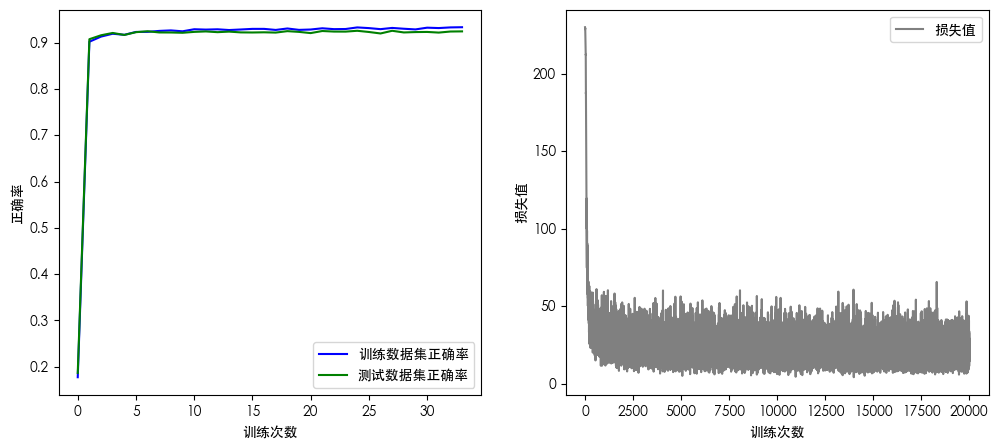

In [8]:
# 超参数  
learning_rate = 0.1 # 学习率
epoch_num = 20000 # 训练次数
hidden_size = 50# 隐藏层大小
start_train(hidden_size, learning_rate, epoch_num)